# Zalora Men's Shirt — Data Cleaning & EDA

**Author:** Adhi Rizqi Alfaqih  
**Date:** 2026  
**Input:** `dataframe.csv`  
**Output:** `dataframe_cleaned.csv`, `dataframe_recommendations.csv`

---

## Project Overview
This notebook processes the raw Zalora men's shirt data collected in `01_scraping.ipynb`. It covers data cleaning, exploratory data analysis (EDA), and product filtering to generate purchase recommendations.

## Objectives
- Clean and validate the raw dataset
- Explore price distribution, rating distribution, and brand popularity
- Filter products based on defined criteria and generate Top 10 recommendations

## Workflow
1. Libraries & Setup
2. Load Data
3. **Part 1** — Data Cleaning
4. **Part 2** — Exploratory Data Analysis
5. **Part 3** — Filtering & Recommendation
6. Conclusion

# Analysis and Product Recommendation for Men's Shirts Using Web Scraping and Data Analysis from Zalora


=================================================

This project aims to collect and analyze men's shirt product data from the Zalora e-commerce platform using web scraping techniques. 
The collected data is then processed through data cleaning, exploratory data analysis (EDA), and filtering based on defined criteria to generate the best product recommendations suited to user needs.

=================================================

# 1. Problem Statement

**Problem:**
- I need several new shirts for various events in the coming week, but I have a limited budget.

**Analysis Goal:**
- Identify men's shirt products that offer the best combination of affordable price, product popularity, and high customer rating.

**Selection Criteria:**
- Product is labeled as "Most Popular"
- Product price is below IDR 500,000
- Product has a high customer rating

# 2. Technical Workflow

Several technologies are used in this project to support the data processing pipeline:

- **Selenium** is used for browser automation during the web scraping process.
- **BeautifulSoup** is used for HTML parsing and extracting product information.
- **Pandas** is used for data cleaning, transformation, and analysis.
- **Matplotlib** and **Seaborn** are used for data visualization in the EDA stage.


## 2.1. Install and Import Library

In [1]:
# Install Pandas for data manipulation
!pip install pandas -q

# Install matplitlib and seaborn for data visualization
!pip install matplotlib -q
!pip install seaborn -q

In [2]:
# Import Pandas for dataframe manipulation
import pandas as pd
# Import matplotlib and seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

## 2.2.Load Data

In [3]:
df = pd.read_csv('dataframe.csv')

print(f'Dataset loaded.')
print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset loaded.
Shape  : (390, 6)
Columns: ['Unnamed: 0', 'Product Name', 'Price', 'Store', 'Rating', 'Most Popular']


,Unnamed: 0,Product Name,Price,Store,Rating,Most Popular
0,0,MOC Kemeja Lengan Panjang Pria THECOOL-WHITE,Rp 299.900,MOC,4.8,NaN
1,1,Platini Kemeja Pria Polos Lengan Pendek Katun ...,Rp 299.000,Platini,4.8,NaN
2,2,Platini Kemeja Pria Lengan Pendek Motif Salur ...,Rp 479.000,Platini,4.8,NaN
3,3,Cotton Rich Overshirt,Rp 999.900,Marks & Spencer,5.0,NaN
4,4,Giordano Men's Short Sleeve Linen Cotton Shirt...,Rp 699.000,Giordano,5.0,Paling Populer


## 2.3. Cleaning Data

Raw scraped data often contains unnecessary characters (such as currency symbols or extra text). 
This stage aims to clean the data so it is ready for numerical analysis.


In [4]:
# Check the number of missing values per column
df.isnull().sum()

Unnamed: 0        0
Product Name      0
Price             0
Store             0
Rating           43
Most Popular    263
dtype: int64

In [5]:
# Check data structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    390 non-null    int64  
 1   Product Name  390 non-null    object 
 2   Price         390 non-null    object 
 3   Store         390 non-null    object 
 4   Rating        347 non-null    float64
 5   Most Popular  127 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 18.4+ KB


In [6]:
# Check for duplicate rows
df.duplicated().sum()

0

In [7]:
# Check for duplicate rows from "Product Name" and "Store"
df.duplicated(subset=['Product Name', 'Store']).sum()

75

The data structure check reveals several issues: 
missing values, duplicate rows, and incorrect data types for the 'Price' and 'Rating' columns, both need to be converted to numeric format, duplicate data from 'product name' and 'store".


In [8]:
# Remove row "Unamed"
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,Product Name,Price,Store,Rating,Most Popular
0,MOC Kemeja Lengan Panjang Pria THECOOL-WHITE,Rp 299.900,MOC,4.8,NaN
1,Platini Kemeja Pria Polos Lengan Pendek Katun ...,Rp 299.000,Platini,4.8,NaN
2,Platini Kemeja Pria Lengan Pendek Motif Salur ...,Rp 479.000,Platini,4.8,NaN
3,Cotton Rich Overshirt,Rp 999.900,Marks & Spencer,5.0,NaN
4,Giordano Men's Short Sleeve Linen Cotton Shirt...,Rp 699.000,Giordano,5.0,Paling Populer


In [9]:
# Clean price column: remove 'Rp', dots, spaces → convert to int
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('Rp', '', regex=False)
    .str.replace('.', '', regex=False)
    .astype(int)
)

# Ensure rating is float
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce').fillna(0.0)

# Ensure 'Most Popular' is int (0 or 1)
df["Most Popular"] = df["Most Popular"].apply(lambda x: 1 if pd.notna(x) else 0)

print('Data types after correction:')
print(df.info())

Data types after correction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  390 non-null    object 
 1   Price         390 non-null    int32  
 2   Store         390 non-null    object 
 3   Rating        390 non-null    float64
 4   Most Popular  390 non-null    int64  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 13.8+ KB
None


In [10]:
# Products with rating 0.0 are likely new products with no reviews yet
df_no_rating = df[df['Rating'] == 0.0]
df_rated     = df[df['Rating'] >  0.0]

print(f'Products without rating (0.0) : {len(df_no_rating)} ({len(df_no_rating)/len(df)*100:.1f}%)')
print(f'Products with rating           : {len(df_rated)} ({len(df_rated)/len(df)*100:.1f}%)')

# Flag unrated products (keep them in cleaned data, exclude from recommendation)
df['has_rating'] = df['Rating'].apply(lambda x: 1 if x > 0.0 else 0)

Products without rating (0.0) : 43 (11.0%)
Products with rating           : 347 (89.0%)


In [11]:
# sorted 'Price' from the cheapest
df = df.sort_values(by='Price', ascending=True)
# remove duplicate from 'Product Name' and 'Store'
df = df.drop_duplicates(subset=['Product Name', 'Store'], keep='first')

Cleaning has been completed. Lets verify the results

In [12]:
df.head()

,Product Name,Price,Store,Rating,Most Popular,has_rating
376,MANZONE - Kemeja Oxford Lengan Pendek Pria Kob...,159900,Manzone,4.9,0,1
348,MANZONE - Kemeja Oxford Lengan Pendek Pria Kob...,159900,Manzone,4.8,1,1
310,MANZONE - Kemeja Oxford Lengan Pendek Pria Rod...,179900,Manzone,4.9,0,1
274,OXCON Easy Shirts Kemeja Tangan Pendek Army,189000,Oxcon,4.9,0,1
40,MOC Kemeja Lengan Pendek Pria PEDRIC-BLACK,189900,MOC,4.7,0,1


In [13]:
# Verify missing values
df.isnull().sum()


Product Name    0
Price           0
Store           0
Rating          0
Most Popular    0
has_rating      0
dtype: int64

In [14]:
# Check for duplicate rows from "Product Name" and "Store"
df.duplicated(subset=['Product Name', 'Store']).sum()

0

**Data cleaning completed successfully:**
1. The 'Paling Populer' column has been converted to binary values: **1** (Most Popular) and **0** (Regular).
2. Missing values in 'Rating' have been replaced with **0**.
3. Currency symbol 'Rp' and thousand separators have been removed from 'Price'.
4. 'Price' has been converted to **int** and 'Product Rating' to **float**.
5. Duplicate rows have been removed.
6. Rows "Unamed" has been removed.

In [15]:
# Display the cleaned DataFrame
print(f'Dataset loaded.')
print(f'Shape  : {df.shape}')
print(f'Columns: {list(df.columns)}')
df

Dataset loaded.
Shape  : (315, 6)
Columns: ['Product Name', 'Price', 'Store', 'Rating', 'Most Popular', 'has_rating']


,Product Name,Price,Store,Rating,Most Popular,has_rating
376,MANZONE - Kemeja Oxford Lengan Pendek Pria Kob...,159900,Manzone,4.9,0,1
348,MANZONE - Kemeja Oxford Lengan Pendek Pria Kob...,159900,Manzone,4.8,1,1
310,MANZONE - Kemeja Oxford Lengan Pendek Pria Rod...,179900,Manzone,4.9,0,1
274,OXCON Easy Shirts Kemeja Tangan Pendek Army,189000,Oxcon,4.9,0,1
40,MOC Kemeja Lengan Pendek Pria PEDRIC-BLACK,189900,MOC,4.7,0,1
...,...,...,...,...,...,...
179,Standard Fit Oxford Shirt,1339000,Gap,5.0,0,1
291,Standard Oxford Shirt,1339000,GAP,4.5,0,1
88,Linen-Cotton Shirt,1359000,GAP,5.0,0,1
204,Cotton Poplin Regular Fit Shirt - BOSS Orange,3159000,BOSS,4.9,0,1


## 2.4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) aims to understand the characteristics of the dataset collected through web scraping. 
In this stage, statistical analysis and data visualization are performed to identify patterns, data distributions, and relationships between variables.

### 2.4.1. Descriptive Statistics

Before visualization, descriptive statistics are examined to get an initial overview of the distribution and characteristics of the data.

In [16]:
# Descriptive statistics for all numeric columns
df.describe()

,Price,Rating,Most Popular,has_rating
count,3.150000e+02,315.000000,315.000000,315.000000
mean,6.070917e+05,4.200952,0.298413,0.869841
std,3.238982e+05,1.650140,0.458290,0.337013
min,1.599000e+05,0.000000,0.000000,0.000000
25%,3.999000e+05,4.700000,0.000000,1.000000
50%,4.699000e+05,4.900000,0.000000,1.000000
75%,7.999000e+05,5.000000,1.000000,1.000000
max,3.159000e+06,5.000000,1.000000,1.000000


### 2.4.2. Price Distribution

Price distribution analysis is conducted to understand the spread of product prices available in the dataset. 
By examining the distribution, we can identify the most common price range and detect products with unusually low or high prices compared to others.

The distribution is visualized using a histogram to show product frequency across each price range.


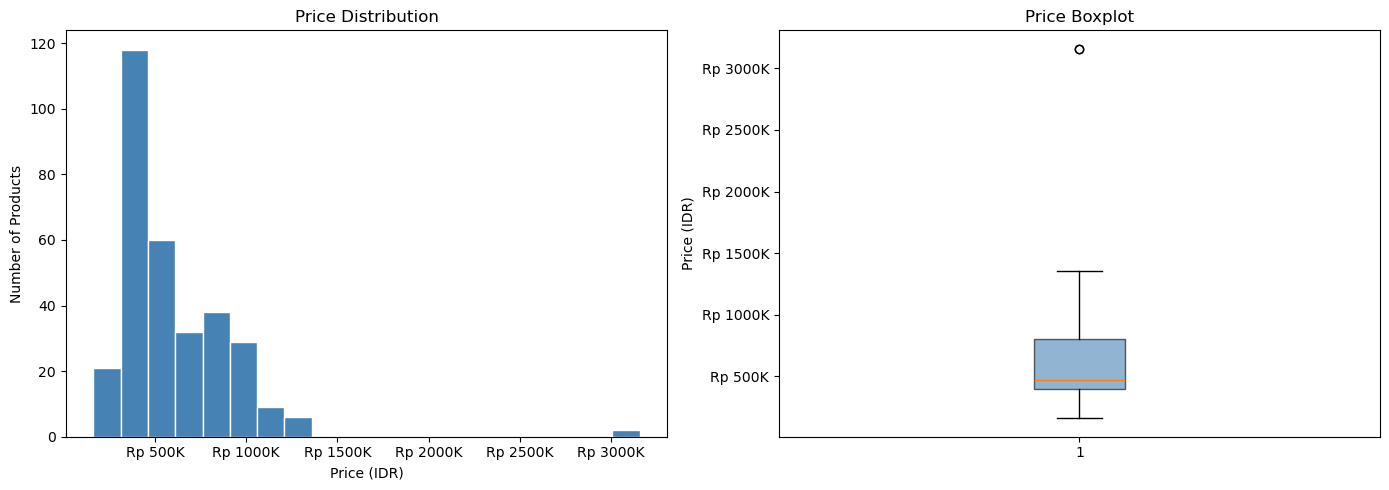

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Price'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (IDR)')
axes[0].set_ylabel('Number of Products')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}K'))

# Boxplot
axes[1].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (IDR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}K'))

plt.tight_layout()
plt.show()

**Key Insights:**

- The price distribution is right-skewed: the majority of products fall within the IDR 400,000–IDR 800,000 range (25th–75th percentiles). This indicates that the men's shirt category on Zalora is dominated by mid-range products that are relatively affordable for consumers.

- There are a few products priced above IDR 1,000,000 that can be categorized as premium products, but their quantity is relatively small compared to mid-range products.

- The majority of shirts in this catalog remain affordable for limited budgets—premium outliers make up only a small fraction and do not represent typical pricing.


### 2.4.3. Top Brands by Product Count

This analysis aims to identify which brands or stores have the highest number of products in the dataset. 
This provides an overview of which brands are most active or dominant in the analyzed product category.


In [32]:
df["Store"].value_counts().head(10)

Store
Marks & Spencer    72
AMK                52
Police Denim       23
Trendyol           16
WOOD               13
MOC                12
Bombboogie          9
Platini             8
NAUTICA             6
Johnwin             6
Name: count, dtype: int64

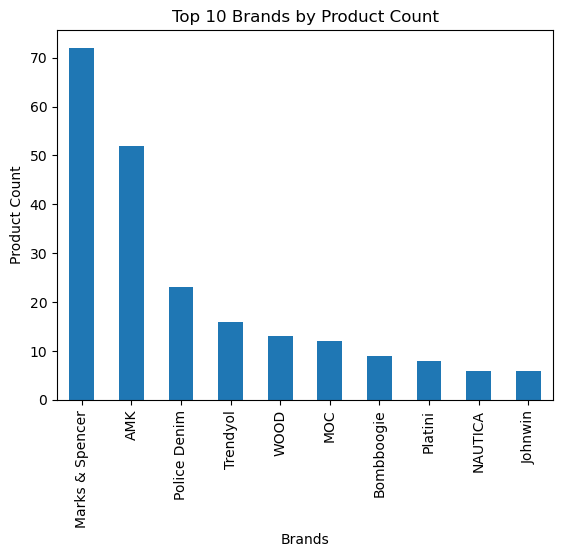

In [33]:
df["Store"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands by Product Count")
plt.xlabel("Brands")
plt.ylabel("Product Count")
plt.show()

Key Insight:

- Marks & Spencer dominates the catalog, followed by AMK and Police Denim; the other seven brands in the top 10 each contribute fewer than 20 products

- This dataset is skewed toward one or two major brands; if you want recommendations that are representative across brands, you need to be careful to ensure that M&S ​​doesn't "dominate" the final results simply due to its high listing volume, rather than superior quality.


### 2.4.4. Rating Distribution

Product rating distribution is analyzed to understand customer satisfaction levels for available products. 
Product rating can be an important indicator for assessing product quality.


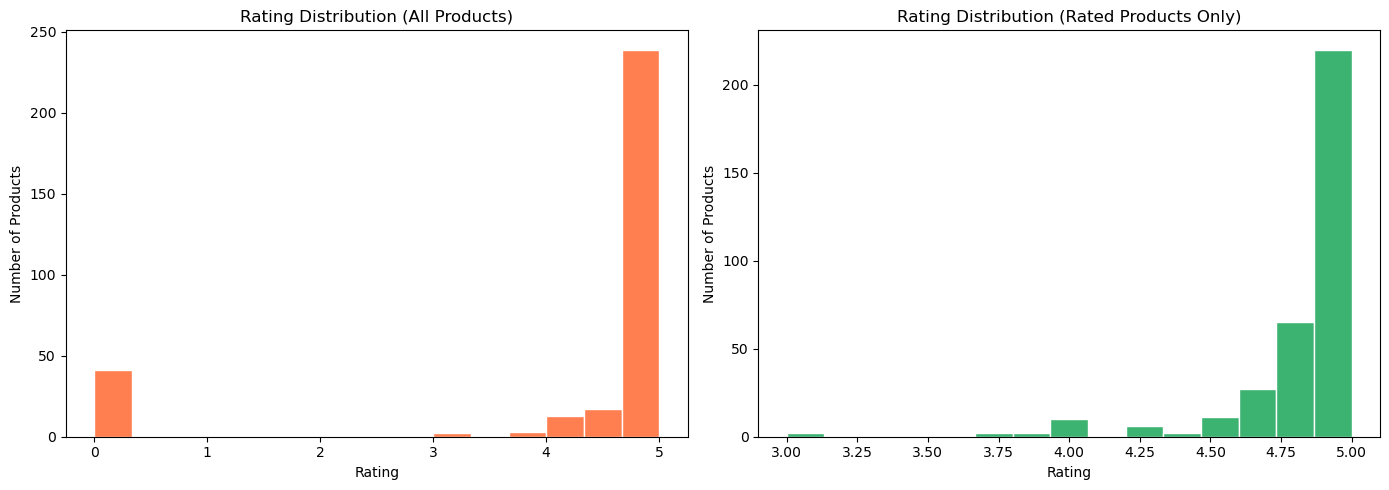

Mean rating (all)   : 4.20
Mean rating (rated) : 4.84


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# All products (including 0.0)
axes[0].hist(df['Rating'], bins=15, color='coral', edgecolor='white')
axes[0].set_title('Rating Distribution (All Products)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Products')

# Rated products only
axes[1].hist(df_rated['Rating'], bins=15, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Rating Distribution (Rated Products Only)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

print(f"Mean rating (all)   : {df['Rating'].mean():.2f}")
print(f"Mean rating (rated) : {df_rated['Rating'].mean():.2f}")

Key Insight:

- The "all products" histogram will show a "cluster" at 0; this high number of zero values ​​is due to the fact that 41 catalog items have no customer ratings, with the value of 0 indicating that these items have not yet been rated.

- Among the products that actually have ratings, the distribution skews heavily toward the high end (with the majority falling between 4.5 and 5.0)—indicating generally high customer satisfaction across the entire catalog.


### 2.4.5. Relationship Between Price and Product Rating

This analysis aims to examine whether there is a relationship between product price and customer rating. 
The visualization is done using a scatter plot.


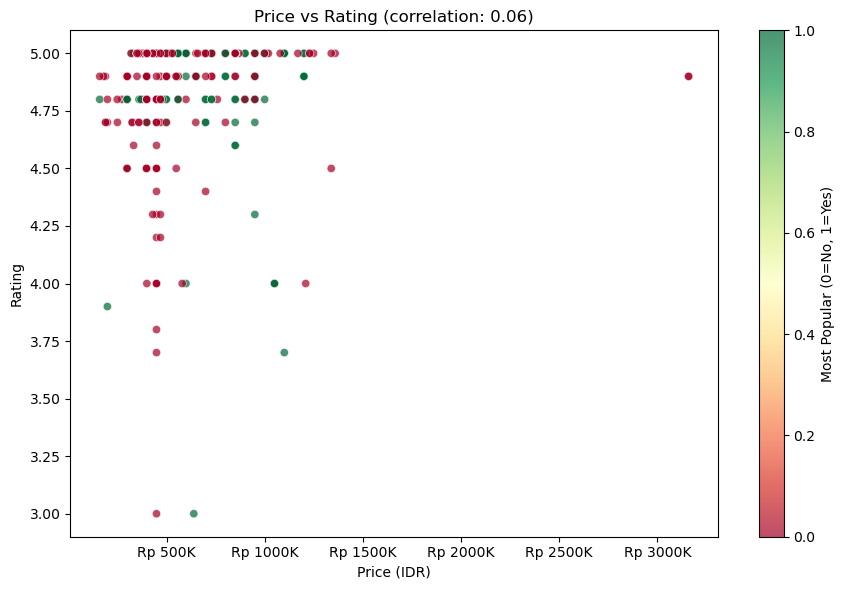

Pearson correlation (price vs rating): 0.0614


In [46]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df_rated['Price'], df_rated['Rating'],
    c=df_rated['Most Popular'], cmap='RdYlGn',
    alpha=0.7, edgecolors='white', linewidth=0.5
)
plt.colorbar(scatter, ax=ax, label='Most Popular (0=No, 1=Yes)')
ax.set_title('Price vs Rating (Rated Products Only)')
ax.set_xlabel('Price (IDR)')
ax.set_ylabel('Rating')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1000:.0f}K'))

corr = df_rated[['Price', 'Rating']].corr().iloc[0, 1]
ax.set_title(f'Price vs Rating (correlation: {corr:.2f})')

plt.tight_layout()
plt.show()

print(f'Pearson correlation (price vs rating): {corr:.4f}')

Key Inisght:

- The Pearson correlation is very weak (r = 0.06)—there is practically no linear relationship between price and rating.

- A low price does not mean a poor rating. Buyers on a limited budget still have plenty of highly-rated shirt options—there is no need to pay a premium for quality.

- Based on popularity: if popular products are evenly distributed across all price points—rather than clustering solely at the high or low end—it reinforces the argument that popularity is not purely a function of price.


### 2.4.6. Most Popular Product Analysis

This analysis is conducted to determine how many products carry the 'Most Popular' label compared to regular products.


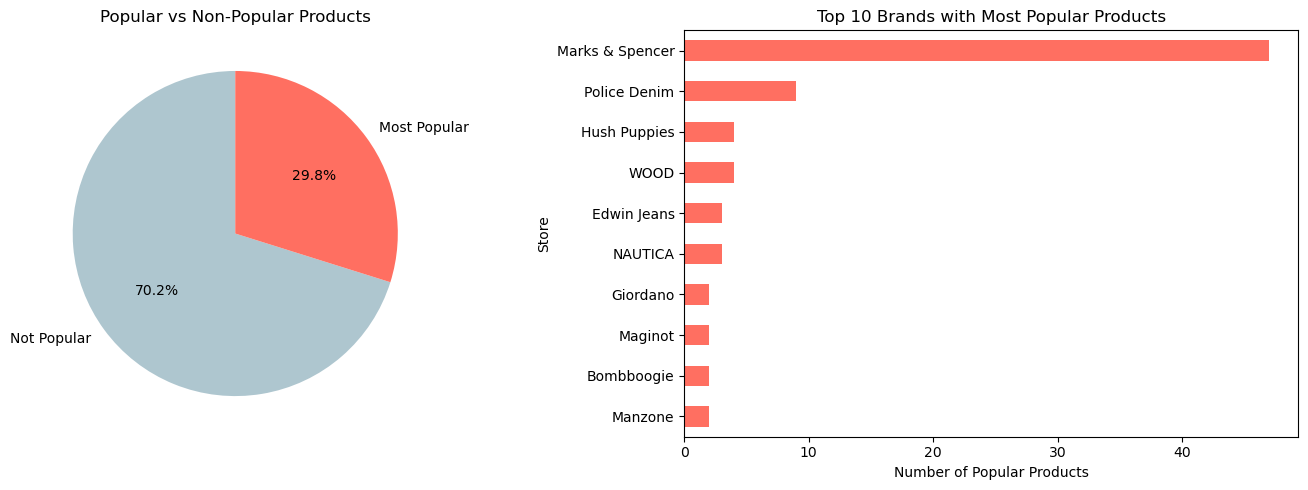

In [50]:
popular_count = df['Most Popular'].value_counts()
labels        = ['Not Popular', 'Most Popular']
colors        = ['#aec6cf', '#ff6f61']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(popular_count, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Popular vs Non-Popular Products')

# Top brands with most popular products
popular_brands = (
    df[df['Most Popular'] == 1]
    .groupby('Store')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
popular_brands.plot(kind='barh', ax=axes[1], color='#ff6f61')
axes[1].set_title('Top 10 Brands with Most Popular Products')
axes[1].set_xlabel('Number of Popular Products')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Key Insight:

- 29.8% of products carry the "Most Popular" label, while 70.2% do not. Insight: this label is quite selective (it is not simply applied to a large number of products), making it a valid and meaningful filtering criterion.

- Marks & Spencer dominates by a wide margin in the "Most Popular" product category across the entire catalog. This means that nearly half of all popular products in this dataset come from a single brand.



### 2.4.7. EDA Summary

Working through this EDA, a few things stood out to me that I think are worth highlighting explicitly rather than leaving readers to infer from the charts alone.

**On price**: the average price (Rp 607K) is a bit misleading on its own — the median (Rp 470K) is a better representation of a "typical" product, since a handful of premium outliers (BOSS, GAP) are pulling the mean upward. Half of the catalog actually sits between Rp 400K–800K, which tells me this is fundamentally an affordable catalog with a few premium exceptions, not a mid-to-premium one.

**On brand concentration**: I checked early on whether this dataset was diverse or dominated by a single seller, and it's the latter — Marks & Spencer alone makes up 72 of 315 products (about 1 in 4 listings). I flagged this for myself because it matters for everything downstream: any "best brand" or "top recommendation" conclusion I draw has to account for the fact that M&S simply has more listings than anyone else, not necessarily better ones.

**On ratings**: this is the finding I'm most careful about. At face value, the "all products" mean rating of 4.20 looks decent but unremarkable. But 41 of those 315 products (13%) were never actually rated by customers — they were filled with a placeholder value of 0, not a genuine low score. Once I isolated the 274 products that do have real reviews, the mean jumped to 4.84. That 4.84 is the number that actually reflects customer sentiment, and it's the one I'd want a reader to take away — reporting 4.20 without this context would understate how well these products are genuinely reviewed.

**On price vs. rating**: this chart answers my original problem statement most directly. The Pearson correlation between Price and Rating is just 0.06 — practically no linear relationship. For someone shopping on a limited budget, that's genuinely good news: paying more does not reliably buy a better-rated shirt in this dataset. This is the strongest evidence I have that budget shoppers aren't sacrificing quality by looking at cheaper options.

**On "Most Popular" as a label**: before using it as a filter criterion, I wanted to check it wasn't just marketing noise attached to most listings. It turned out to be fairly selective — only 93 of 315 products (29.5%) carry the tag — so I treated it as a meaningful signal rather than something too common to be useful.

**On popular products by brand**: this is where the brand concentration issue resurfaces. Of the 93 "Most Popular" products, 45 (nearly half) are from Marks & Spencer. So when a filtered recommendation later lands on an M&S product, it's worth being upfront that this partly reflects catalog composition — M&S has more listings and more "Most Popular" tags to begin with — rather than being purely a verdict on product merit.

**Bottom line**: price is a poor predictor of quality in this catalog, genuine customer satisfaction is high once unrated products are excluded, and any brand-level conclusion should be read with Marks & Spencer's outsized share of the catalog in mind.

## 2.5. Product Filtering

To obtain product recommendations that match the user's needs, the dataset is filtered based on the following pre-defined criteria.

**Filtering Criteria:**
- Product is labeled as "Most Popular"
- Product price is below IDR 500,000
- Product has best customer rating


In [23]:
recommendations = df[
    (df["Price"] < 500000) &
    (df["Most Popular"] == 1) &
    (df["Rating"] > 0.0) # Only products with a valid rating
]

print(f"Number of products meeting all criteria: {len(recommendations)} products")
dataframe_recommendations = recommendations.sort_values(['Rating', 'Price'], ascending=[False, True]).head(10)
dataframe_recommendations


Number of products meeting all criteria: 32 products


,Product Name,Price,Store,Rating,Most Popular,has_rating
198,Gloaming Kemeja Flanel Veterano Unisex Averin,320000,Gloaming,5.0,1,1
210,Slim Fit Short Sleeve Check Shirt,329900,Executive,5.0,1,1
251,Cuban Viking Blue Casual Shirt,359000,VENGOZ,5.0,1,1
252,POLICE Kemeja Polos Cotton Regular Fit Pria,399000,Police Denim,5.0,1,1
142,POLICE Kemeja Polos Jeans Regular Fit Pria,399000,Police Denim,5.0,1,1
47,Short Sleeve Checks Shirt with Pocket,399900,WOOD,5.0,1,1
108,Kemeja Regular Pria Vertiline,419900,Bombboogie,5.0,1,1
25,Relaxed Fit Long Sleeve Stripe Shirt,429900,WOOD,5.0,1,1
97,Regular Fit Long Sleeve Stripe Shirt,429900,WOOD,5.0,1,1
259,Kemeja Regular Pria Mora,439900,Bombboogie,5.0,1,1


## 2.6. Analysis Limitations

Several limitations to consider when interpreting the results of this analysis:

1. **Limited Data Coverage** — Data was only collected from the first 10 pages of the men's shirt sale category on Zalora, and therefore does not represent the full product catalog.
2. **Dynamic Data** — Prices, ratings, and 'Most Popular' labels can change at any time. The analysis results are only relevant at the time of data collection.
3. **Rating Unavailability** — Products without customer reviews have no rating and therefore cannot be included in rating-based filtering.
4. **HTML Structure Dependency** — The scraping script relies on Zalora's HTML class names and attributes, which can change at any time and may require the script to be updated accordingly.


# 3. Conclusion

This analysis set out to answer a practical question: given a limited budget, which men's shirts on Zalora offer the best combination of affordability, popularity, and customer satisfaction?

After cleaning 390 scraped listings down to 315 valid, deduplicated products, the EDA revealed a few key patterns:

1. **Price and rating are essentially uncorrelated** (Pearson r = 0.06) — a lower price does not mean a lower rating, so a limited budget does not have to mean a compromise on quality.
2. **Genuine customer satisfaction is high**: once the 41 unrated products (13%) are excluded, the average rating among rated products is 4.84 out of 5.
3. **"Most Popular" is a meaningful, selective label** (29.5% of listings), making it a useful filtering criterion rather than a marketing formality.
4. **Marks & Spencer** is the most represented brand in the catalog (72 of 315 listings, and 45 of 93 "Most Popular" products) — a factor worth keeping in mind so that any brand-level conclusion isn't mistaken for a verdict on quality alone.

Applying the three defined filtering criteria — **Most Popular = Yes, Price < Rp 500,000, and a valid customer rating** — narrowed the 315-product catalog down to **32 qualifying products**. Ranking them by rating (descending) and price (ascending) shows that the top 10 candidates all carry a perfect 5.0 rating, priced between Rp 320,000–Rp 440,000, and span a genuinely diverse set of brands (Gloaming, Executive, VENGOZ, Police Denim, WOOD, Bombboogie, and others) — no single brand dominates this shortlist.

**In short**: for a shopper with a Rp 500,000 budget, there is no shortage of well-reviewed, popular shirt options — 32 products meet every criterion, and the top 10 alone offer a genuinely diverse set of brands, all rated 5.0. Price constraints do not appear to limit access to quality in this catalog. The complete filtered list is available in `dataframe_recommendation.csv`; the full filtering logic and its limitations are documented in Sections 2.5–2.7.

# 4. Save Data

## 4.1. Export DataFrame to CSV

In [ ]:
# Export cleaned DataFrame to CSV
df.to_csv('dataframe_cleaned.csv')index=False


In [ ]:
# Export filtered recommendations to CSV
dataframe_recommendations.to_csv('dataframe_recommendation.csv')index=False
